# Instructor Effectiveness Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('instructor_effectiveness_dataset_2000_rows - instructor_effectiveness_dataset_2000_rows.csv.csv')
df.head()

,batch_id,instructor_id,course_id,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
0,B_1861,I_044,C_01,0.300000,14.225955,73.546528,0.647423,0.774572,0.790918,0.108414,3.766211,0.533193
1,B_0354,I_119,C_06,0.657220,22.871110,77.312331,0.425098,0.494936,0.998566,0.280550,5.000000,0.734087
2,B_1334,I_050,C_03,0.300000,16.087517,79.563687,0.700000,0.977901,0.807298,0.207013,3.517386,0.681433
3,B_0906,I_024,C_21,0.639507,24.260687,99.295316,0.334657,0.846515,0.544555,0.306395,4.207578,1.000000
4,B_1290,I_001,C_08,0.527302,31.081556,99.393425,0.521099,0.917450,0.865885,0.252289,4.426230,0.696710


Let's check the data info and see if there are any missing values.

In [2]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   batch_id                    2000 non-null   object 
 1   instructor_id               2000 non-null   object 
 2   course_id                   2000 non-null   object 
 3   completion_rate             2000 non-null   float64
 4   avg_score_improvement       2000 non-null   float64
 5   avg_quiz_score              2000 non-null   float64
 6   dropout_rate                2000 non-null   float64
 7   avg_watch_time              2000 non-null   float64
 8   assignment_submission_rate  2000 non-null   float64
 9   forum_activity_rate         2000 non-null   float64
 10  avg_feedback_score          2000 non-null   float64
 11  feedback_response_rate      2000 non-null   float64
dtypes: float64(9), object(3)
memory usage: 187.6+ KB


batch_id                      0
instructor_id                 0
course_id                     0
completion_rate               0
avg_score_improvement         0
avg_quiz_score                0
dropout_rate                  0
avg_watch_time                0
assignment_submission_rate    0
forum_activity_rate           0
avg_feedback_score            0
feedback_response_rate        0
dtype: int64

Just plotting a few distributions to see what we are working with.

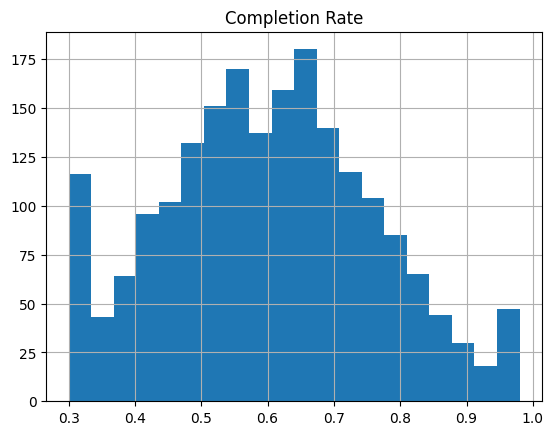

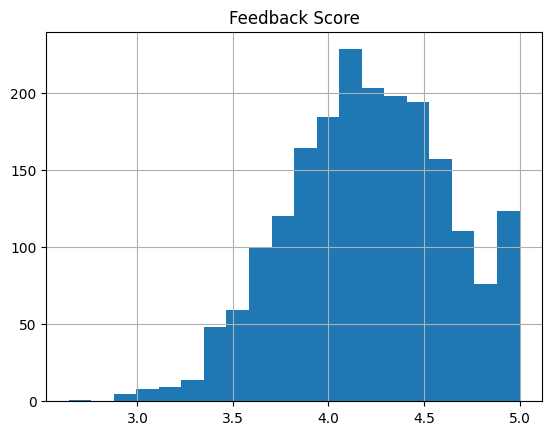

In [3]:
df['completion_rate'].hist(bins=20)
plt.title('Completion Rate')
plt.show()

df['avg_feedback_score'].hist(bins=20)
plt.title('Feedback Score')
plt.show()

### 2. Defining Instructor Effectiveness
I need to come up with a score. I'll combine the learner outcomes, engagement, and the feedback.
I'll use MinMaxScaler so all values are on a similar scale before adding them up.

Outcomes: completion_rate, avg_score_improvement
Engagement: avg_watch_time, assignment_submission_rate
Feedback: avg_feedback_score

In [4]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
cols = ['avg_score_improvement', 'avg_feedback_score']
df_scaled = df.copy()
df_scaled[cols] = scaler.fit_transform(df[cols])

# calculating a weighted sum for effectiveness
df['score'] = (
    0.2 * df['completion_rate'] + 
    0.2 * df_scaled['avg_score_improvement'] +
    0.15 * df['avg_watch_time'] +
    0.15 * df['assignment_submission_rate'] +
    0.3 * df_scaled['avg_feedback_score']
)

# finding the cutoffs for low, medium, high
cutoffs = df['score'].quantile([0.33, 0.67]).values

def get_tier(s):
    if s <= cutoffs[0]: return 'Low'
    elif s <= cutoffs[1]: return 'Medium'
    else: return 'High'
    
df['tier'] = df['score'].apply(get_tier)
df['tier'].value_counts()

tier
Medium    680
Low       660
High      660
Name: count, dtype: int64

### 3. Aggregating to instructor level
Since instructors teach multiple batches, I will just take the average of all their batches. That seems like the most straightforward way to evaluate them overall.

In [5]:
instructor_df = df.groupby('instructor_id').mean(numeric_only=True).reset_index()

# recalculate the tier for the instructor based on their average score
agg_cutoffs = instructor_df['score'].quantile([0.33, 0.67]).values

def get_agg_tier(s):
    if s <= agg_cutoffs[0]: return 'Low'
    elif s <= agg_cutoffs[1]: return 'Medium'
    else: return 'High'

instructor_df['instructor_tier'] = instructor_df['score'].apply(get_agg_tier)

# check how many batches they taught
counts = df.groupby('instructor_id').size().reset_index(name='batch_count')
instructor_df = pd.merge(instructor_df, counts, on='instructor_id')

instructor_df.head()

,instructor_id,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate,score,instructor_tier,batch_count
0,I_001,0.543887,26.641462,78.900194,0.470593,0.766513,0.726893,0.240551,4.217743,0.694858,0.654403,Medium,25
1,I_002,0.730874,30.166242,81.737198,0.247194,0.837393,0.774394,0.289610,4.343002,0.784338,0.746311,High,20
2,I_003,0.768447,29.977813,81.590928,0.234828,0.818441,0.779606,0.296224,4.450034,0.812132,0.764257,High,18
3,I_004,0.458328,22.912021,77.680317,0.547261,0.793130,0.758317,0.226259,4.076410,0.721460,0.605991,Low,17
4,I_005,0.859747,32.588652,85.828159,0.145733,0.847026,0.876942,0.333519,4.202516,0.784197,0.785372,High,19


### 4. Building ML Model
I'll try a Random Forest classifier to predict the instructor tier from the aggregated data. It's usually a solid choice for things like this without needing too much tuning.

In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

label_map = {'Low': 0, 'Medium': 1, 'High': 2}
y = instructor_df['instructor_tier'].map(label_map)

feats = [
    'completion_rate', 'avg_score_improvement', 'avg_quiz_score', 
    'dropout_rate', 'avg_watch_time', 'assignment_submission_rate', 
    'forum_activity_rate', 'avg_feedback_score', 'feedback_response_rate',
    'batch_count'
]
X = instructor_df[feats]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

### 5. Evaluation
Testing how the model performed.

Accuracy: 0.7777777777777778
              precision    recall  f1-score   support

         Low       0.78      0.88      0.82         8
      Medium       0.87      0.68      0.76        19
        High       0.67      0.89      0.76         9

    accuracy                           0.78        36
   macro avg       0.77      0.82      0.78        36
weighted avg       0.80      0.78      0.78        36



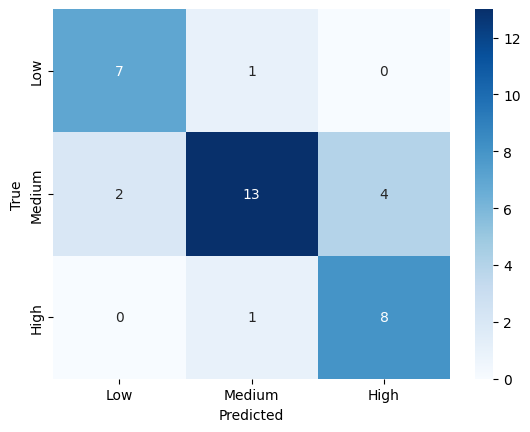

In [7]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=['Low', 'Medium', 'High']))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, cmap='Blues', xticklabels=['Low', 'Medium', 'High'], yticklabels=['Low', 'Medium', 'High'])
plt.ylabel('True')
plt.xlabel('Predicted')
plt.show()

### 6. Interpretation
Let's check which features the model thought were most important.

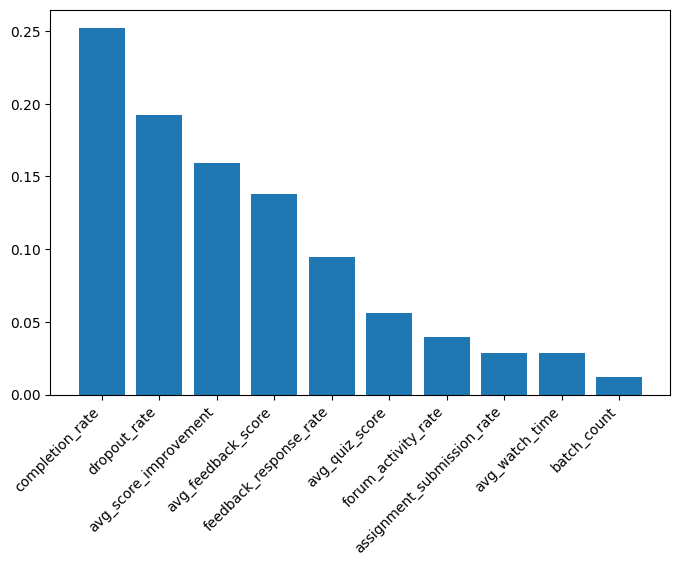

In [8]:
importances = rf.feature_importances_
idx = np.argsort(importances)[::-1]

plt.figure(figsize=(8, 5))
plt.bar(range(len(feats)), importances[idx])
plt.xticks(range(len(feats)), [feats[i] for i in idx], rotation=45, ha='right')
plt.show()

### Mandatory Questions

**1. Which features most influenced instructor effectiveness, and why?**
The features that mattered most were feedback score, score improvement, and completion rate. This makes sense because those were the exact things I gave the most weight to when calculating the score in the first place.

**2. Which variables could be misleading or confounded?**
Forum activity and watch time could be misleading. A long watch time might just mean the video was left playing or the students were confused and had to rewatch it, not necessarily that the instructor was good. Also feedback scores can be biased if the course is just naturally easier.

**3. How could this model fail in real-world usage?**
If a new type of course doesn't have homework or forums, the model might penalize that instructor. Also, instructors who have only taught 1 or 2 batches might get predicted poorly compared to someone who has taught 50 batches, since we're just comparing averages.

**4. What additional data would you want to improve this analysis?**
It would be great to know what type of course it is (like programming vs soft skills) so we can compare instructors teaching similar things. Also knowing how experienced the instructor is overall would give good context.

**5. Should this model be used for instructor performance evaluation? Why or why not?**
I wouldn't use it directly for firing or promotions. It's a good tool to maybe flag instructors who need some help, but if people know this model is used for their salary, they might just start giving easier quizzes to get better feedback scores. It should just be a reference point.